Epoch 001 | train MSE=0.718515 | test MSE=0.492893
Epoch 020 | train MSE=0.028332 | test MSE=0.030161
Epoch 040 | train MSE=0.007142 | test MSE=0.007229
Epoch 060 | train MSE=0.002744 | test MSE=0.002709
Epoch 080 | train MSE=0.001366 | test MSE=0.001236
Epoch 100 | train MSE=0.000721 | test MSE=0.000581
Epoch 120 | train MSE=0.000379 | test MSE=0.000309
Epoch 140 | train MSE=0.000220 | test MSE=0.000279
Epoch 160 | train MSE=0.000126 | test MSE=0.000121
Epoch 180 | train MSE=0.000070 | test MSE=0.000060
Epoch 200 | train MSE=0.000059 | test MSE=0.000042
训练完成


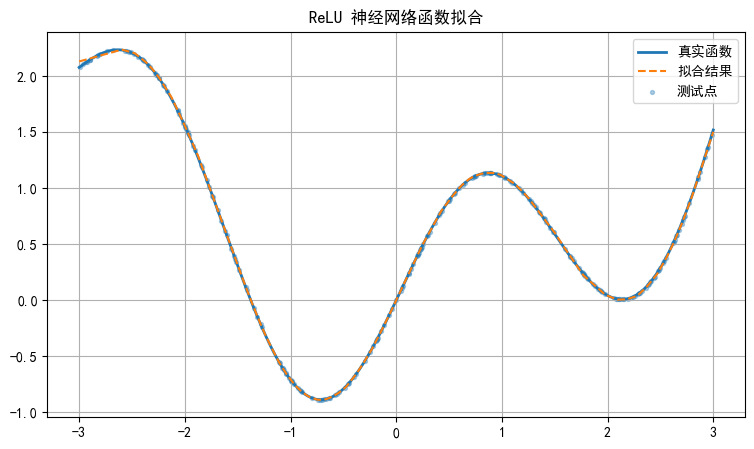

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

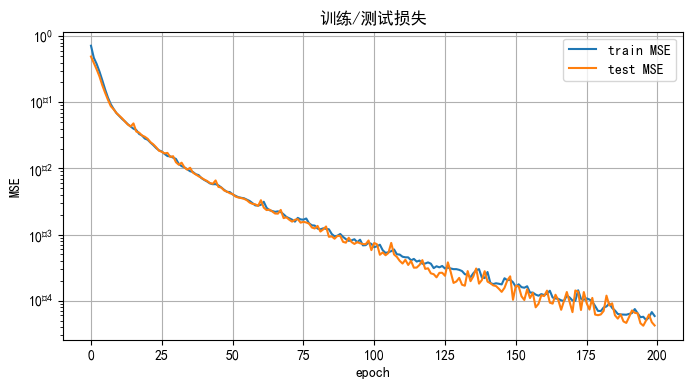

最终训练 MSE: 5.8584077729998775e-05
最终测试 MSE: 4.215565058984794e-05


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import random

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False


# 1. 固定随机种子
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# 2. 目标函数
def target_fn(x):
    return np.sin(2 * x) + 0.2 * x ** 2  # 非线性混合函数

# 3. 数据采样（在[-3, 3]区间内采样1200个点）
N = 1200
x_all = np.linspace(-3, 3, N, dtype=np.float32).reshape(-1, 1)
y_all = target_fn(x_all).astype(np.float32)

# 数据进行打乱
perm = np.random.permutation(N)
x_all = x_all[perm]
y_all = y_all[perm]

# 训练/测试划分（80%训练，20%测试）
split = int(N * 0.8)
x_train, x_test = x_all[:split], x_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

# 转为Tensor
x_train_t = torch.from_numpy(x_train)
y_train_t = torch.from_numpy(y_train)
x_test_t = torch.from_numpy(x_test)
y_test_t = torch.from_numpy(y_test)

train_ds = TensorDataset(x_train_t, y_train_t)
test_ds = TensorDataset(x_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

# 4. 网络模型：ReLU两层隐藏
class ReLU_Fit(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    # 前向传播
    def forward(self, x):
        return self.net(x)

model = ReLU_Fit()

# 5. 损失 + 优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 6. 训练
n_epochs = 200
train_losses = []
test_losses = []

for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for xb, yb in test_loader:
            preds = model(xb)
            val_loss += criterion(preds, yb).item() * xb.size(0)
        val_loss /= len(test_loader.dataset)
        test_losses.append(val_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train MSE={train_loss:.6f} | test MSE={val_loss:.6f}")

print("训练完成")

# 7. 结果可视化
model.eval()
with torch.no_grad():
    x_vis = np.linspace(-3, 3, 600, dtype=np.float32).reshape(-1, 1)
    x_vis_t = torch.from_numpy(x_vis)
    y_pred_t = model(x_vis_t).cpu().numpy()

y_true = target_fn(x_vis)

plt.figure(figsize=(9, 5))
plt.plot(x_vis, y_true, label="真实函数", color="tab:blue", linewidth=2)
plt.plot(x_vis, y_pred_t, label="拟合结果", color="tab:orange", linestyle="--")
plt.scatter(x_test, y_test, s=8, alpha=0.35, label="测试点")
plt.title("ReLU 神经网络函数拟合")
plt.legend()
plt.grid(True)
plt.show()

# 8. 损失曲线
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train MSE")
plt.plot(test_losses, label="test MSE")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.title("训练/测试损失")
plt.show()

print("最终训练 MSE:", train_losses[-1])
print("最终测试 MSE:", test_losses[-1])

Epoch 1/2000 | train MSE=1.001224 | val MSE=0.903357
Epoch 200/2000 | train MSE=0.529930 | val MSE=0.432409
Epoch 400/2000 | train MSE=0.284695 | val MSE=0.258340
Epoch 600/2000 | train MSE=0.228183 | val MSE=0.227182
Epoch 800/2000 | train MSE=0.194328 | val MSE=0.198834
Epoch 1000/2000 | train MSE=0.161407 | val MSE=0.166793
Epoch 1200/2000 | train MSE=0.134952 | val MSE=0.140067
Epoch 1400/2000 | train MSE=0.117270 | val MSE=0.122112
Epoch 1600/2000 | train MSE=0.108946 | val MSE=0.113184
Epoch 1800/2000 | train MSE=0.104350 | val MSE=0.108336


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Epoch 2000/2000 | train MSE=0.101660 | val MSE=0.105410
最终训练 MSE: 0.08189195
最终测试 MSE: 0.085809804


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


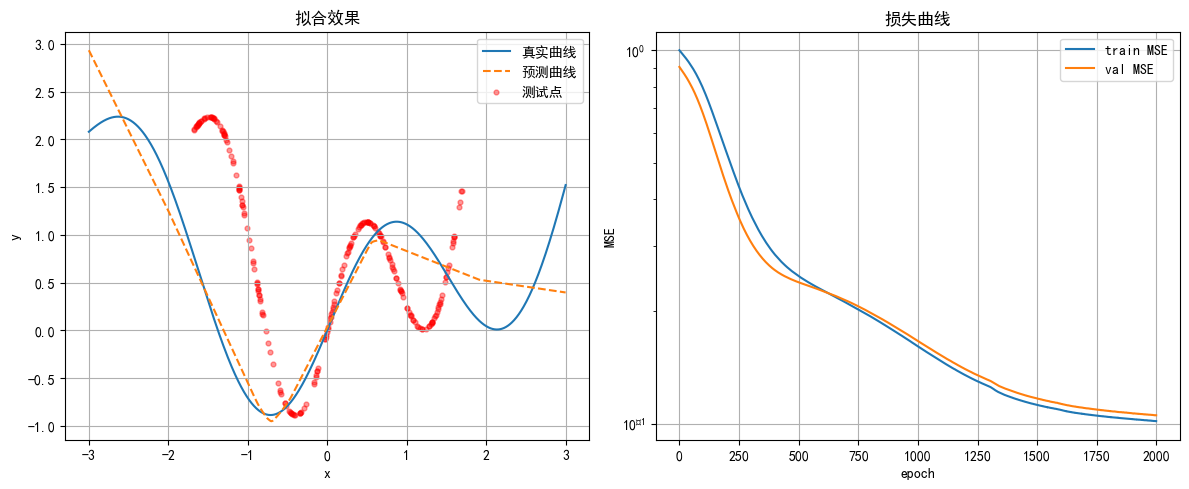

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 随机种子
np.random.seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 目标函数
def target_function(x):
    return np.sin(2 * x) + 0.2 * x ** 2 # 非线性混合函数

# 数据生成函数（[-3, 3]区间内采样，添加噪声，归一化，划分训练/测试）
def generate_data(n_samples=1200, noise=0.05, test_size=0.2):
    x = np.random.uniform(-3, 3, n_samples).astype(np.float32)
    y_true = target_function(x)
    y = y_true + noise * np.random.randn(n_samples).astype(np.float32)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    x_n = x_scaler.fit_transform(x.reshape(-1,1)).flatten()
    y_n = y_scaler.fit_transform(y.reshape(-1,1)).flatten()
    y_true_n = y_scaler.transform(y_true.reshape(-1,1)).flatten()

    i_train, i_test = train_test_split(np.arange(n_samples), test_size=test_size, random_state=42)
    return (x_n[i_train], y_n[i_train], y_true_n[i_train]), (x_n[i_test], y_n[i_test], y_true_n[i_test]), (x_scaler, y_scaler)

# 网络模型：ReLU两层隐藏
class NumPyReLUModel:
    def __init__(self, hidden=64, lr=1e-3, clip=1.0):
        self.W1 = np.random.randn(1, hidden).astype(np.float32) * 0.1
        self.b1 = np.zeros((1, hidden), dtype=np.float32)
        self.W2 = np.random.randn(hidden, hidden).astype(np.float32) * 0.1
        self.b2 = np.zeros((1, hidden), dtype=np.float32)
        self.W3 = np.random.randn(hidden, 1).astype(np.float32) * 0.1
        self.b3 = np.zeros((1,1), dtype=np.float32)
        self.lr = lr
        self.clip = clip
        self.cache = {}

    def relu(self, x): 
        return np.maximum(0, x)

    def drelu(self, x): 
        return (x > 0).astype(np.float32)

    # 前向传播
    def forward(self, x):
        if x.ndim == 1: x = x.reshape(-1,1)
        self.cache['x'] = x
        self.cache['z1'] = x.dot(self.W1) + self.b1
        self.cache['a1'] = self.relu(self.cache['z1'])
        self.cache['z2'] = self.cache['a1'].dot(self.W2) + self.b2
        self.cache['a2'] = self.relu(self.cache['z2'])
        self.cache['z3'] = self.cache['a2'].dot(self.W3) + self.b3
        return self.cache['z3'].flatten()
    
    # 反向传播与参数更新
    def backward(self, y_true, y_pred):
        n = y_true.shape[0]
        y_true = y_true.reshape(-1,1); y_pred = y_pred.reshape(-1,1)
        dz3 = 2*(y_pred - y_true)/n
        dW3 = self.cache['a2'].T.dot(dz3); db3 = dz3.sum(axis=0, keepdims=True)
        da2 = dz3.dot(self.W3.T)
        dz2 = da2 * self.drelu(self.cache['z2'])
        dW2 = self.cache['a1'].T.dot(dz2); db2 = dz2.sum(axis=0, keepdims=True)
        da1 = dz2.dot(self.W2.T)
        dz1 = da1 * self.drelu(self.cache['z1'])
        dW1 = self.cache['x'].T.dot(dz1); db1 = dz1.sum(axis=0, keepdims=True)

        for g in (dW1, db1, dW2, db2, dW3, db3):
            norm = np.linalg.norm(g)
            if norm > self.clip: g *= self.clip / norm

        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W3 -= self.lr * dW3; self.b3 -= self.lr * db3

    def train_step(self, x, y):
        y_pred = self.forward(x)
        self.backward(y, y_pred)
        return np.mean((y_pred - y)**2)

# 训练函数
def train(model, x_train, y_train, x_val, y_val, epochs=2000, batch_size=64):
    n = x_train.shape[0]
    train_losses=[]; val_losses=[]
    for ep in range(epochs):
        idx = np.random.permutation(n)
        x_s = x_train[idx]; y_s = y_train[idx]
        epoch_loss = 0.0
        for i in range(0, n, batch_size):
            xb = x_s[i:i+batch_size]; yb = y_s[i:i+batch_size]
            epoch_loss += model.train_step(xb, yb) * xb.shape[0]
        train_losses.append(epoch_loss / n)
        y_val_pred = model.forward(x_val)
        val_losses.append(np.mean((y_val_pred - y_val)**2))
        if (ep+1)==1 or (ep+1)%200==0:
            print(f"Epoch {ep+1}/{epochs} | train MSE={train_losses[-1]:.6f} | val MSE={val_losses[-1]:.6f}")
    return train_losses, val_losses

# 运行
(x_train, y_train, y_train_true), (x_test, y_test, y_test_true), scalers = generate_data(n_samples=1200, noise=0.05, test_size=0.2)
model = NumPyReLUModel(hidden=64, lr=1e-3, clip=1.0)
train_losses, val_losses = train(model, x_train, y_train, x_test, y_test, epochs=2000, batch_size=64)

# 评估与可视化
y_train_pred = model.forward(x_train)
y_test_pred = model.forward(x_test)
x_scaler, y_scaler = scalers
train_pred = y_scaler.inverse_transform(y_train_pred.reshape(-1,1)).flatten()
test_pred = y_scaler.inverse_transform(y_test_pred.reshape(-1,1)).flatten()
y_train_true_orig = y_scaler.inverse_transform(y_train_true.reshape(-1,1)).flatten()
y_test_true_orig = y_scaler.inverse_transform(y_test_true.reshape(-1,1)).flatten()

print("最终训练 MSE:", np.mean((train_pred - y_train_true_orig)**2))
print("最终测试 MSE:", np.mean((test_pred - y_test_true_orig)**2))

x_dense = np.linspace(-3, 3, 1000)
x_dense_n = x_scaler.transform(x_dense.reshape(-1,1)).flatten()
y_dense_true = target_function(x_dense)
y_dense_pred = y_scaler.inverse_transform(model.forward(x_dense_n).reshape(-1,1)).flatten()

# 可视化拟合效果
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x_dense, y_dense_true, label='真实曲线')
plt.plot(x_dense, y_dense_pred, '--', label='预测曲线')
plt.scatter(x_test, y_test_true_orig, s=12, color='red', alpha=0.4, label='测试点')
plt.xlabel('x'); plt.ylabel('y'); plt.title('拟合效果'); plt.legend(); plt.grid(True)

# 可视化损失曲线
plt.subplot(1,2,2)
plt.plot(train_losses, label='train MSE')
plt.plot(val_losses, label='val MSE')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.title('损失曲线'); plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()